# **Comparison of Integrators : Leapfrog and Euler Method**

The following notebooks explains the Euler method of numerical integration, it's shortcomings, the Leapfrog method and the comparison between both the integration methods.


### Comparison of the Integrators

#### What is an integrator?

An integrator is a numerical tool for solving differential equations step by step over time. It takes the system's current state and the rate of change to estimate the system’s next state after a small time increment.

#### Integration methods:
#### 1. **Euler Method:**

It works by using the current rate of change (slope) to estimate the next value after a small time step. For a differential equation,
$\frac{dy}{dt}=f(t,y)$
The Euler update rule is,

$$y_{n+1} = y_n + f(y_n, t_n ) \Delta t$$

For example, if $x$ = position and $v$ = velocity, then by using Euler method

$$x_{n+1} = x_n + v_n \Delta t$$

$$v_{n+1} = v_n + a_n \Delta t$$


**Limitations of Euler's Method:**

The main limitation of Euler's method is that the system artificially gains or loses energy at each step. This happens because the method only uses the current slope, assuming it stays constant over the entire timestamp, but since real motion follows a curved trajectory, errors accumulate systematically over time, causing the total energy to drift upward or downward instead of remaining constant. Consider a harmonic system where $F = -kx$. For ease, consider $k=m=1$ in the example below.

Thus,  $$\frac{d^2x}{dt^2} = -x$$

Also,  $$\frac{dx}{dt} = v$$

$$\frac{dv}{dt} = -x$$

$$ E = \frac{1}{2}v^2 + \frac{1}{2}x^2 $$

Suppose,

Initial position: $x_0 = 1$
Initial velocity: $v_0 = 0$
Timestamp: $\Delta t$ = 0.1
Initial Energy: $E_0$ = 0.5

After using Euler's Method,

$$x_{n+1} = x_n + v_nΔt$$

$$v_{n+1} = v_n - x_nΔt$$

Thus, updating the position and velocity

$$v_1 = 0-(1)(0.1) = -0.1$$
$$x_1 = 1 + (0)(0.1) = 1$$


 Therefore,

 $$E_1 = \frac{1}{2}[x_1]^2 + \frac{1}{2}[v_1]^2$$

 $$E_1 = 0.505$$

But initial energy was $E_0 = 0.5$

Therefore, energy has increased, and the planet will spiral outward even when the system's energy should be conserved. Now, this limitation is overcome by using the Leapfrog Integrator



### 2.  **Leapfrog Integrator**


The leapfrog integrator is a numerical method for solving equations of motion with staggered half-steps. This makes the method more symmetric in time and better aligned with true curved motion of the system. The motion uses more centred information, so errors cancel out more effectively. Thus, the geometry of the real system is preserved.

Given positions $\mathbf{r}$, velocities $\mathbf{v}$, accelerations $\mathbf{a}$, and timestep $\Delta t$:

1. Kick
Update velocity by half step:

$$
\mathbf{v}_{n+\frac{1}{2}}=
\mathbf{v}_{n}
+
\frac{\Delta t}{2}\,\mathbf{a}_{n}
$$

2. Drift
Update position using half-step velocity:

$$
\mathbf{x}_{n+1} =
\mathbf{x}_{n}
+
\Delta t\,\mathbf{v}_{n+\frac{1}{2}}
$$

3. Compute New Acceleration
Using the updated positions:

$$
\mathbf{a}_{n+1} =
\frac{\mathbf{F}(\mathbf{x}_{n+1})}{m}
$$

4. Kick
Complete the velocity update:

$$
\mathbf{v}_{n+1}=
\mathbf{v}_{n+\frac{1}{2}}
+
\frac{\Delta t}{2}\,\mathbf{a}_{n+1}
$$

In [1]:
#Necessary Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
print("Libraries have been imported")

#Constants
G = 6.67430e-11          # Gravitational constant
M = 1.989e30             # Mass of Sun (kg)
R = 6.957e8              # Radius of Sun (m)
AU = 1.496e11            # Astronomical Unit (m)
N_steps = 250
print("Constants have been set")

#Standardizations
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,})
# ------------------------------------------------- #

#Using 2D arrays for data storage
positions = np.zeros((N_steps, 2))
velocities = np.zeros((N_steps, 2))
times = np.zeros(N_steps)
energies = np.zeros(N_steps)
print("Standardizations have been set")

Libraries have been imported
Constants have been set
Standardizations have been set


Libraries have been imported,
Constants have been set,
Standardizations have been set

In [2]:
#Core Physical Functions
def gravitational_force(r, m1, m2):
  r_mag = np.linalg.norm(r)
  return -G * m1 * m2 * r / r_mag**3

def gravitational_potential(r, m1, m2):
    r_mag = np.linalg.norm(r)
    return -G * m1 * m2 / r_mag

def gravitational_acceleration(r):
  r_mag = np.linalg.norm(r)
  if r_mag < 1e-10:      # To avoid singularity at origin
        raise ValueError("Planet has reached the star")
  return -G*M / r_mag**3 * r

def kinetic_energy(m, v):
    return 0.5 * m * np.dot(v, v)

def total_energy(m, r, v):
    r_mag = np.linalg.norm(r)
    return 0.5 * m * np.dot(v, v) - (G * M) / r_mag

def angular_momentum(m, r, v):
    return m * np.cross(r, v)

This subsection shows numerically the difference between Euler and Leapfrog schemes. 

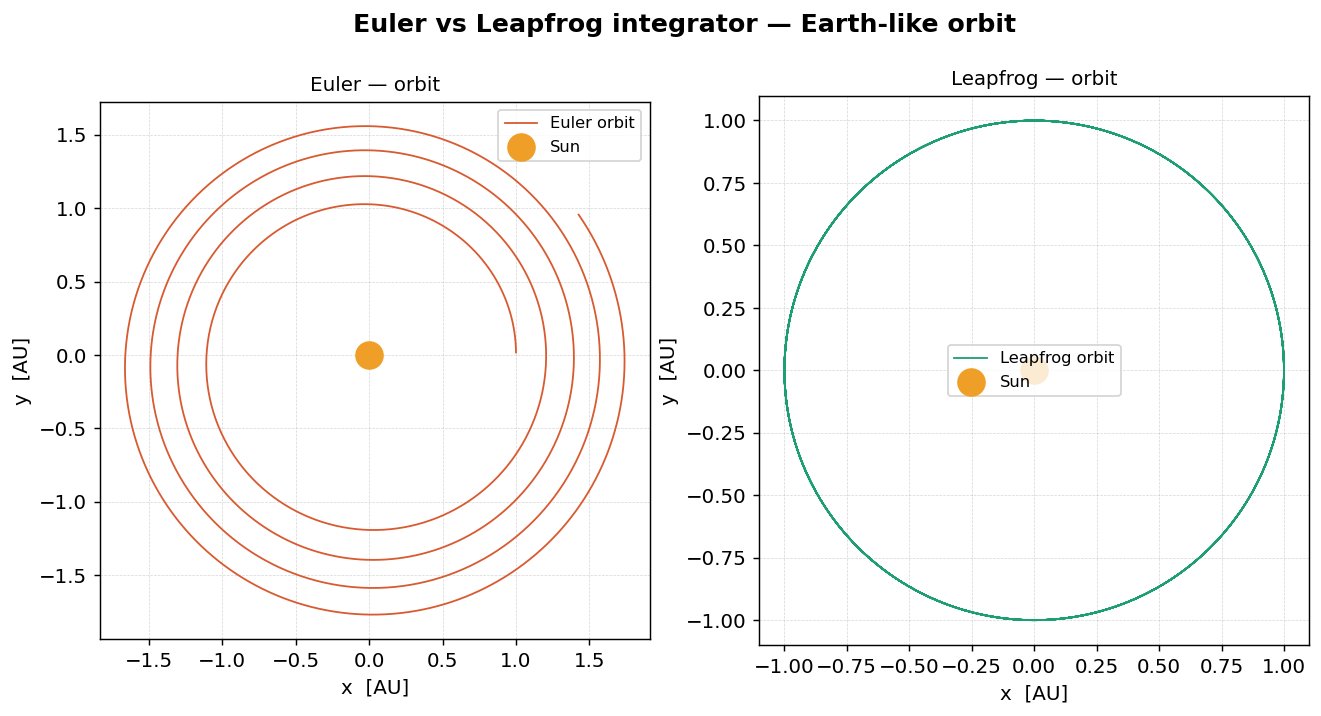

In [3]:
# ── Shared initial conditions ─────────────────────────────────────────────────
X0, Y0   = AU, 0.0        # Initial position             [m]
VX0, VY0 = 0.0, 29_780.0  # Initial velocity (circular)  [m/s]

dt      = 24 * 3600  # Time step: 1 day             [s]
N_steps = 2500       # Total steps ≈ 6.85 years

# ---------------------------------------------------------------------------- #

x, y   = X0, Y0
vx, vy = VX0, VY0

eu_x, eu_y = [], []
eu_E,  eu_L = [], []

for _ in range(N_steps):
    r  = np.sqrt(x**2 + y**2)
    ax = -G * M * x / r**3     # acceleration at current position
    ay = -G * M * y / r**3

    # Position update (uses current velocity)
    x += vx * dt
    y += vy * dt

    # Velocity update (uses acceleration evaluated at the OLD position)
    vx += ax * dt
    vy += ay * dt

    eu_x.append(x)
    eu_y.append(y)

# ---------------------------------------------------------------------------- #

x, y   = X0, Y0
vx, vy = VX0, VY0

lf_x, lf_y = [], []
lf_E,  lf_L = [], []

r  = np.sqrt(x**2 + y**2)
ax = -G * M * x / r**3
ay = -G * M * y / r**3

for _ in range(N_steps):
    # ½-step velocity
    vx_h = vx + 0.5 * ax * dt
    vy_h = vy + 0.5 * ay * dt

    # Full-step position
    x += vx_h * dt
    y += vy_h * dt

    # New acceleration at updated position
    r  = np.sqrt(x**2 + y**2)
    ax = -G * M * x / r**3
    ay = -G * M * y / r**3

    # ½-step velocity (complete the full step)
    vx = vx_h + 0.5 * ax * dt
    vy = vy_h + 0.5 * ay * dt

    lf_x.append(x)
    lf_y.append(y)
steps  = np.arange(N_steps)

fig, axes = plt.subplots(1, 2, figsize=(12, 10))
fig.suptitle("Euler vs Leapfrog integrator — Earth-like orbit", fontsize=14,
             fontweight="bold")
plt.subplots_adjust(top=1.3)
C_EU = "#D85A30"
C_LF = "#1D9E75"

# ── Panel A: Euler orbit ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(np.array(eu_x) / AU, np.array(eu_y) / AU,
        color=C_EU, lw=1, label="Euler orbit")
ax.scatter(0, 0, s=220, color="#EF9F27", zorder=5, label="Sun")
ax.set_title("Euler — orbit", fontsize=11)
ax.set_xlabel("x  [AU]")
ax.set_ylabel("y  [AU]")
ax.set_aspect("equal")
ax.legend(fontsize=9)
ax.grid(True, ls="--", lw=0.4, alpha=0.5)

# ── Panel B: Leapfrog orbit ───────────────────────────────────────────────────
ax = axes[1]
ax.plot(np.array(lf_x) / AU, np.array(lf_y) / AU,
        color=C_LF, lw=1, label="Leapfrog orbit")
ax.scatter(0, 0, s=220, color="#EF9F27", zorder=5, label="Sun")
ax.set_title("Leapfrog — orbit", fontsize=11)
ax.set_xlabel("x  [AU]")
ax.set_ylabel("y  [AU]")
ax.set_aspect("equal")
ax.legend(fontsize=9)
ax.grid(True, ls="--", lw=0.4, alpha=0.5)